# **DBSCAN**

**DBSCAN** stands for **Density-Based Spatial Clustering of Applications with Noise**. 

Unlike K-Means, which forces every single point into a cluster and assumes clusters are round, DBSCAN is a rebel. It groups points based on how densely packed they are. If it finds a point hanging out all by itself in an empty space, it simply labels it as "Noise" (an outlier) and ignores it!

Here is an in-depth breakdown of how it works in simple words.


### Part 1: The Core Idea

Imagine you are looking at a crowded stadium from above.
1.  **High Density:** Where people are standing shoulder-to-shoulder, that's a cluster.
2.  **Low Density:** A few people walking alone in the parking lot are outliers (noise).

DBSCAN works exactly like this. It wanders through your data, finding areas where data points are tightly packed together. It expands these areas to form clusters, and any points left stranded in low-density zones are marked as noise.


### Part 2: The Two Magic Parameters

To make DBSCAN work, you only need to tell it two things:

**1. `eps` (Epsilon)**
*   **What it is:** The maximum distance between two points for them to be considered "neighbors".
*   **Simple Words:** Imagine giving every data point a hula hoop of a specific radius (`eps`). If another point falls inside that hula hoop, they are neighbors!
*   **How to tune:** If `eps` is too small, most data will be called "Noise" because the hula hoops won't touch. If `eps` is too big, all the points will merge into one giant, useless cluster.

**2. `min_samples`**
*   **What it is:** The minimum number of points (including the point itself) that must exist inside a hula hoop (`eps` radius) to be considered a "Core Point".
*   **Simple Words:** "How big does a crowd need to be before we officially call it a cluster?"
*   **How to tune:** For a 2D dataset, `min_samples` of 4 is the standard default. If your data is very noisy, increase this number to force the algorithm to only find highly dense, clear clusters.


### Part 3: The Three Types of Points

Once you set `eps` and `min_samples`, DBSCAN categorizes every single data point into one of three buckets:

**1. Core Points (The VIPs)**
*   A point is a "Core Point" if it has at least `min_samples` number of neighbors inside its `eps` hula hoop. These are the hearts of your clusters.
*   Core point is such a data point, of whose in `eps` neighborhood the number of data points is greater than or equal to `min_samples`

**2. Border Points (The +1s)**
*   A point is a "Border Point" if it *does not* have enough neighbors to be a Core Point, BUT it happens to fall inside the hula hoop of a Core Point. It gets to join the cluster because it knows a VIP.
*   Border point is such point where it has less number of data points in its `eps` neighbourhood, but it has atleast one core point in its `eps` neighborhood.

**3. Noise / Outliers (The Loners)**
*   A point is "Noise" if it doesn't have enough neighbors AND it doesn't fall inside any Core Point's hula hoop. DBSCAN assigns these points a label of `-1`.

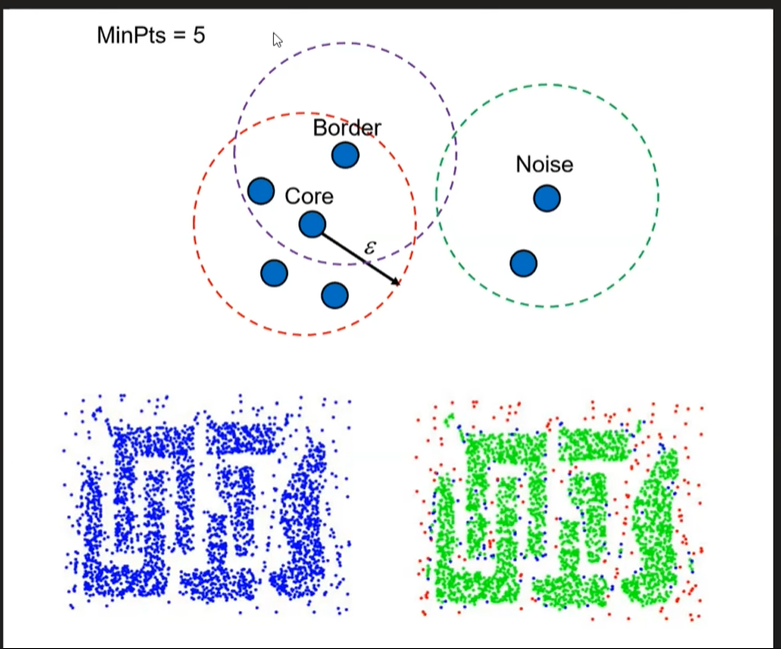


### Part 4: The "Chain Reaction" (Reachability vs. Connectivity)

To truly understand how DBSCAN builds its clusters, it helps to understand three formal terms the algorithm uses to link points together: **Directly Density-Reachable**, **Density-Reachable**, and **Density-Connected**.

Here is how the chain reaction works:

#### 1. Directly Density-Reachable (The Immediate Neighbors)
Imagine Point A is a massive VIP (A Core Point). Point B happens to be standing inside Point A's hula hoop (within `eps` distance). 
*   Because Point A is a Core Point, and Point B is right next to it, we say that Point B is **Directly Density-Reachable** from Point A. 
*   *Note:* It’s a one-way street! If Point B is just a Border Point (not a VIP), Point A can "reach" Point B, but Point B doesn't have the power to "reach" anyone.

#### 2. Density-Reachable (The Friend of a Friend)
Now imagine Point A (a Core Point) reaches its neighbor, Point B (also a Core Point). Point B then reaches its own neighbor, Point C.
*   Even though Point A and Point C are miles apart and their hula hoops don't touch, they are connected by a chain of Core Points. 
*   We say Point C is **Density-Reachable** from Point A. This chain reaction is exactly how DBSCAN builds massive clusters of any shape!


#### 3. Density-Connected (The Ultimate Cluster Link)
This brings us to the final rule of how a cluster is defined. 
Let's say Point X and Point Y are at opposite ends of a huge, crescent-shaped cluster. Neither one can reach the other. However, there is a giant Core Point right in the middle (Point Z).
*   Point Z can reach Point X.
*   Point Z can also reach Point Y.
*   Because they share a common ancestor that can reach both of them, we say Point X and Point Y are **Density-Connected**.


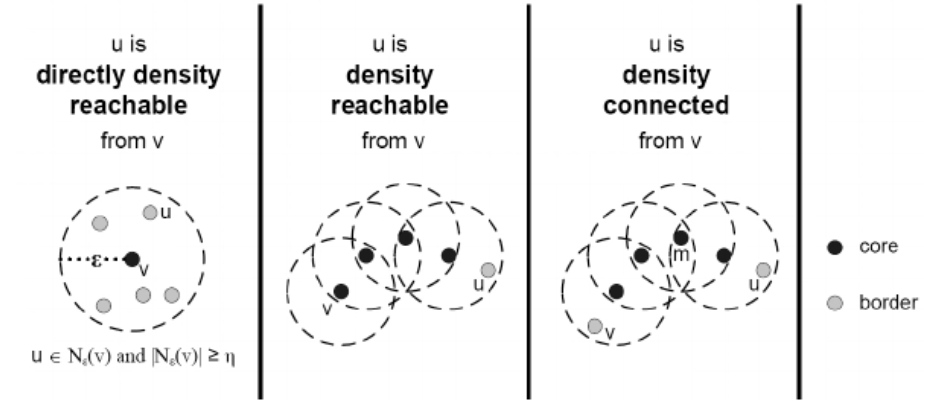
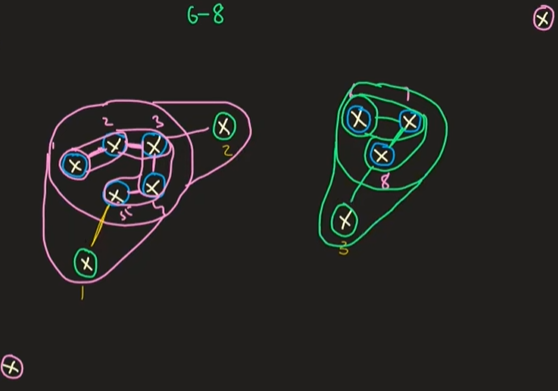

**The Golden Rule of DBSCAN:** A "Cluster" is simply a group of points where *every single point* in the group is **Density-Connected** to every other point!


### Part 5: How the Algorithm Actually Runs

Here is the step-by-step logic DBSCAN follows behind the scenes:

1.  **Pick a random point** that hasn't been visited yet.
2.  **Check its hula hoop:** Count how many neighbors are within the `eps` distance.
3.  **Is it a Core Point?** If it has enough neighbors (`>= min_samples`), a new cluster is born! 
4.  **Expand the cluster:** The algorithm looks at all the neighbors. If any of *those* neighbors are also Core Points, it pulls their neighbors into the cluster too. This chain reaction continues until the dense area completely runs out.
5.  **Is it Noise?** If the random point we picked in Step 1 didn't have enough neighbors, it's temporarily marked as "Noise". (It might later become a Border Point if a nearby Core Point expands into it).
6.  **Repeat** until every single point has been visited.


### Pros and Cons of DBSCAN

#### Why it's amazing (Pros):
*   **No guessing:** You do NOT need to tell it how many clusters to look for (unlike K-Means where you must pick `K`).
*   **Weird shapes:** It can find clusters surrounded by other clusters, crescent shapes, or completely arbitrary blobs. Can find arbitary shaped clusters.
*   **Built-in outlier detection:** It naturally identifies and isolates anomalies (Noise).
*   **Robust to outliers**
*   **Only two hyperparameters to tune**


#### Where it struggles (Cons):
*   **Varying densities:** If your dataset has one cluster that is extremely dense and another cluster that is very spread out, DBSCAN will struggle. A single `eps` value won't work perfectly for both.
*   **High Dimensions:** In datasets with hundreds of features (dimensions), the concept of "distance" breaks down (the Curse of Dimensionality), making it very hard to pick a good `eps`.
*   **A simple tweking in parameters will lead to very drastic change is the number of clusters**
*   **You can't make prediction with DBSCAN, only used for clustering.**